In [8]:
import numpy as np

a = [8, 9, 7, 9, 6, 3, 10, 9, 5, 5, 8, 9]

sum = 0
for t in a: sum += t
print(sum)

avg = sum/len(a)
print(avg)

ss = np.sum([(t-avg)**2 for t in a]) / (len(a) - 1)
print(ss)

print(np.var(a, ddof=1))

88
7.333333333333333
4.6060606060606055
4.6060606060606055


In [15]:
import numpy as np

a = np.array([8, 9, 7, 9, 6, 3, 10, 9, 5, 5, 8, 9]).reshape(2, 6)
print(a)
avg = np.mean(a, axis=1)
print(avg)

[[ 8  9  7  9  6  3]
 [10  9  5  5  8  9]]
[7.         7.66666667]


In [31]:
import numpy as np

X = np.array([[8, 9, 7, 9, 6, 3, 10, 9, 5, 5, 8, 9], 
[7, 7, 6, 5, 5, 3, 7, 8, 6, 2, 3, 6]])

m = np.mean(X, axis=1).reshape(2, 1)
# print(m)

X = X - m
# print(X)

mycov = X @ X.T
mycov /= (X.shape[1] - 1)
print(mycov)

print(np.cov(X))

[[4.60606061 2.57575758]
 [2.57575758 3.53787879]]
[[4.60606061 2.57575758]
 [2.57575758 3.53787879]]


[1.07933269e+01 2.12945512e+00 7.36300330e-02 1.28874947e-02
 2.74822668e-03 1.57044980e-03 2.96554425e-05]


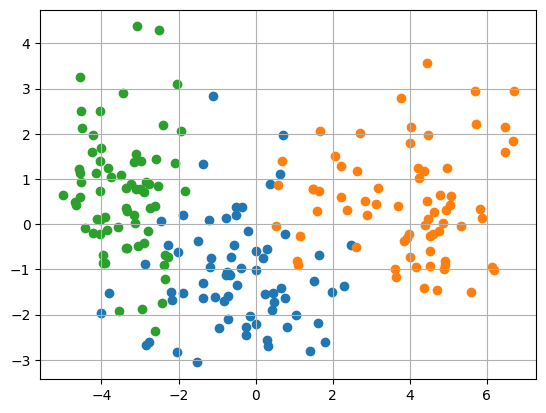

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


rawdata = np.loadtxt('seeds_dataset.txt', delimiter='\t')

data = rawdata[:,:-1]

cats = rawdata[:,-1]
cat1Idx = np.where(cats==1)
cat2Idx = np.where(cats==2)
cat3Idx = np.where(cats==3)

pca = PCA(n_components=2)

transformed = pca.fit_transform(data)

plt.scatter(transformed[cat1Idx, 0], transformed[cat1Idx, 1])
plt.scatter(transformed[cat2Idx, 0], transformed[cat2Idx, 1])
plt.scatter(transformed[cat3Idx, 0], transformed[cat3Idx, 1])
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

img = plt.imread('palomino_horse.png')
img = img[:,:,0]
# print(img.shape)

n_components = 60

mean = np.mean(img, axis=0)
X_centered = img - mean
# X_centered = img

X_cov = np.cov(X_centered, rowvar=False)

vals, vects = np.linalg.eig(X_cov)

sorted_index = np.argsort(vals)[::-1]

sorted_vals = vects[:,sorted_index]

components = sorted_vals[:, :n_components]
transformed = X_centered @ components

# print(transformed.shape)
restored = transformed @ components.T
plt.imshow(restored, cmap='grey')
plt.show()

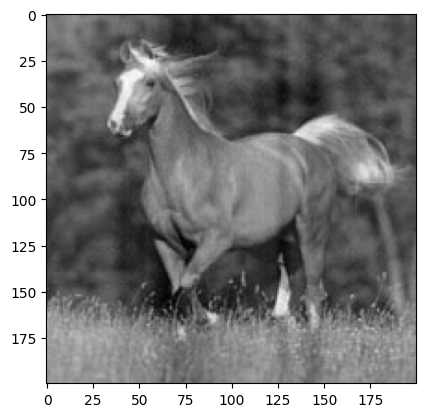

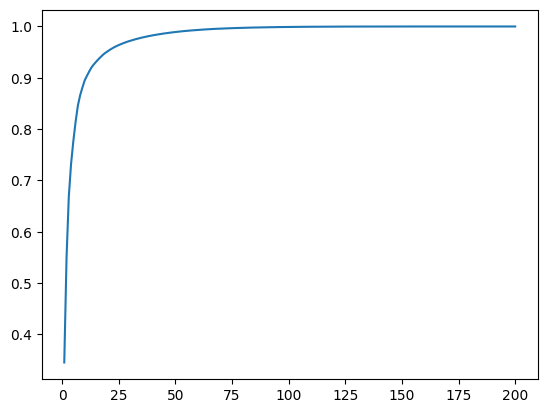

In [37]:
import numpy as np
import matplotlib.pyplot as plt

img = plt.imread('palomino_horse.png')
img = img[:,:,0]
# print(img.shape)

n_components = 60

mean = np.mean(img, axis=0)
X_centered = img - mean
# X_centered = img

X_cov = np.cov(X_centered, rowvar=False)

vals, vects = np.linalg.eig(X_cov)

sorted_index = np.argsort(vals)[::-1]

sorted_vects = vects[:,sorted_index]
sorted_vals = vals[sorted_index]

components = sorted_vects[:, :n_components]
transformed = X_centered @ components

# print(transformed.shape)
restored = transformed @ components.T
plt.imshow(restored, cmap='grey')
plt.show()

sorted_vals = sorted_vals / np.sum(sorted_vals)

cumvals = np.cumsum(sorted_vals)

plt.plot(range(1, len(cumvals)+1), cumvals)
plt.show()